# Código de auxílio para o desenho do LGR

Código criado para a disciplina Projeto de Sistemas de Controle. Ele percorre os 10 passos para desenhar um LGR e os 2 passos para saber se um ponto pertence ao LGR.

Aviso, ele não te forneçe o gráfico final, apenas um esboço com as informações importantes para o desenho completo.

## Código de auxílio

In [2]:
# Bibliotecas utilizadas
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, I, Abs, re, im, Poly
from sympy.physics.control import *
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
from collections import Counter
import plotly.graph_objects as go

In [3]:
# Símbolos utilizados
s, k = sp.symbols('s k')

In [4]:
def polinomio(entrada):
    '''
    Função que transforma coeficientes em polinômios
    '''
    coeficientes = entrada.strip().split()  # Transforma a entrada em uma lista de strings e remove espaços extras
    coeficientes.reverse() # Inverte a lista
    lista_polinomio = []

    # Percorre de trás para frente para começar pelo maior expoente
    for exp in range(len(coeficientes) - 1, -1, -1):
        coef = coeficientes[exp]

        # Pula coeficientes que são zero
        if coef == "0":
            continue

        # Formata o termo dependendo do expoente
        if exp > 1:
            termo = f"{coef}*s**{exp}"
        elif exp == 1:
            termo = f"{coef}*s"
        else:
            termo = f"{coef}"

        lista_polinomio.append(termo)

    return " + ".join(lista_polinomio)


In [5]:
def lgr_eixo_real(polos, zeros, grande = -10):
    '''
    Função que retorna trechos reais lgr
    '''
    polos_reais = [polo for polo in polos if polo.imag == 0]
    zeros_reais = [zero for zero in zeros if zero.imag == 0]

    polos_zeros = polos_reais + zeros_reais
    polos_zeros.sort(reverse=True)
    i = 1
    linhas = []
    for ponto in polos_zeros:
        if(i % 2 == 1):
            inicio = ponto
        else:
            final = ponto
            linhas.append([inicio, final])
        i+=1
    if(i % 2 == 0): # Terminou com linha até o infinito
        linhas.append([inicio, grande])
    print("Segmentos do eixo real LGR:")
    for linha in linhas:
        print(linha)
    return linhas

In [6]:
def lugares_separados(polos, zeros):
    n_polos = len(polos)
    n_zeros = len(zeros)
    if(n_polos >= n_zeros):
        ls = n_polos
    else:
        ls = n_zeros
    print(f"O número de lugares separados é {ls}")
    return n_polos, n_zeros

In [7]:
def assintotas_zeros_infinitos(polos, zeros, n_polos, n_zeros):
    n_assintotas = n_polos - n_zeros

    # Cálculo de sigma
    soma_real = 0
    for polo in polos:
        parte_real = re(polo)
        soma_real += parte_real
    for zero in zeros:
        parte_real = re(zero)
        soma_real -= parte_real

    sigma = soma_real/(n_polos - n_zeros)

    #Cálculo do angulo das assintotas
    angulos_assintotas = []
    for q in range(n_polos - n_zeros): # 0, 1, 2, ..., (np - nz- 1)
        phi = (2*q + 1) *180/(n_polos - n_zeros)
        angulos_assintotas.append(phi)
    print(f"{n_assintotas} assintotas para zeros infinitos")
    print(f"As assintotas são centralizadas em {sigma:.2f}")
    print(f"As assintotas tem ângulo: {angulos_assintotas}")
    return sigma, angulos_assintotas

In [35]:
def plot_assintotas(ax, ponto, angulos, comprimento=10):
    x0, y0 = ponto

    for angulo in angulos:
        theta = np.radians(angulo)

        x1 = x0 + comprimento * np.cos(theta)
        y1 = y0 + comprimento * np.sin(theta)

        ax.plot([x0, x1], [y0, y1], linestyle='--')

    ax.scatter(x0, y0, color='black', zorder=3, label = "sigma", marker='P')
    ax.legend()


In [9]:
def raizes_derivada(ft):
    # Inverso negativo: -1 / ft
    # Converte o objeto de controle em uma expressão matemática comum do SymPy
    ft_expressao = ft.to_expr()

    # Agora você pode usar o sp.cancel() e fazer operações com números normalmente
    ft_inverso_negativo = sp.cancel(-1 / ft_expressao)
    ft_inverso_negativo
    df = sp.diff(ft_inverso_negativo, s)

    raizes = sp.solve(df, s)
    raizes_numericas = [complex(r.evalf()) for r in raizes]
    print("Raízes das derivadas:")
    for raiz in raizes_numericas:
        print(raiz)
    return raizes_numericas


In [10]:
def calc_ponto_saida(raizes, linhas):   
    ponto_saida = []

    for raiz in raizes:
        if abs(im(raiz)) < 1e-60: # Leva em consideração erros de aproximação
            for linha in linhas:
                if re(raiz) > linha[1] and re(raiz) < linha[0]:
                    ponto_saida.append(raiz)
    print(f"Ponto de saída:")
    for ponto in ponto_saida:
        print(f"{ponto:.2f}")
    return ponto_saida

In [11]:
def tabela_routh_lgr(G, H, k):
    s = G.var

    # Equação característica:
    # D_G(s)*D_H(s) + k*N_G(s)*N_H(s) = 0

    polinomio = sp.expand(
        G.den * H.den +
        k * G.num * H.num
    )

    pol = sp.Poly(polinomio, s)

    coef = pol.all_coeffs()

    n = len(coef) - 1
    colunas = (n + 2) // 2

    tabela = sp.zeros(n + 1, colunas)

    tabela[0, :len(coef[0::2])] = sp.Matrix([coef[0::2]])
    tabela[1, :len(coef[1::2])] = sp.Matrix([coef[1::2]])

    for i in range(2, n + 1):
        for j in range(colunas - 1):
            a = tabela[i - 2, 0]
            b = tabela[i - 2, j + 1]
            c = tabela[i - 1, 0]
            d = tabela[i - 1, j + 1]

            tabela[i, j] = sp.simplify((c*b - a*d) / c)

    return tabela

In [12]:
def k_criticos_positivos(R, k):
    primeira_coluna = [sp.factor(R[i, 0]) for i in range(R.rows)]

    k_criticos = []

    for elemento in primeira_coluna:

        solucoes = sp.solve(elemento, k)

        for sol in solucoes:

            # Verifica se a solução é real e positiva
            if sol.is_real and sol >= 0:
                if sol not in k_criticos:
                    k_criticos.append(sol)

    return k_criticos

In [13]:
def resolver_linha_s2(R, k_criticos, s, k):
    """
    Recebe:
        R            -> tabela de Routh
        k_criticos   -> lista de ganhos críticos
        s            -> símbolo da variável s
        k            -> símbolo do ganho

    Retorna:
        Polos encontrados ao resolver a linha s^2 para cada K crítico.
    """

    # Índice da linha s^2:
    # linha s^n -> índice 0
    # ...
    # linha s^2 -> índice n - 2
    n = R.rows - 1
    indice_s2 = n - 2

    # Verifica se existe linha s^2
    if indice_s2 < 0:
        raise ValueError("A tabela não possui uma linha s^2.")

    # Pega os elementos da linha s^2
    linha_s2 = list(R[indice_s2, :])

    # Remove zeros do final
    while linha_s2 and linha_s2[-1] == 0:
        linha_s2.pop()

    # Constrói o polinômio da linha s^2
    # Exemplo: [1, 3] -> s^2 + 3
    polinomio_s2 = sum(
        linha_s2[j] * s**(2 - 2*j)
        for j in range(len(linha_s2))
    )

    print("Linha s^2:")
    display(polinomio_s2)

    resultados = []

    for kc in k_criticos:

        # Substitui o ganho crítico
        polinomio_k = sp.factor(
            polinomio_s2.subs(k, kc)
        )

        # Resolve a equação da linha s^2
        polos = sp.solve(
            sp.Eq(polinomio_k, 0),
            s
        )

        resultados.append(polos)

        print(f"\nK crítico = {kc}")
        print("Equação:")
        display(sp.Eq(polinomio_k, 0))

        print("Polos:")
        for polo in polos:
            sp.pprint(complex(polo.evalf()))

    return resultados

In [14]:
def angulo(v):
    """Retorna o argumento de um número complexo em graus."""
    return float(sp.deg(sp.arg(v)))


In [15]:

def angulo_partida(polo, polos, zeros):
    """
    Calcula o ângulo de partida de um polo complexo.

    polo  : polo de onde o ramo parte
    polos : lista com todos os polos
    zeros : lista com todos os zeros

    Retorna o ângulo em graus, no intervalo [-180, 180).
    """

    # Soma dos ângulos dos outros polos
    soma_polos = 0

    for p in polos:
        if p != polo:
            soma_polos += angulo(polo - p)

    # Soma dos ângulos dos zeros
    soma_zeros = 0

    for z in zeros:
        soma_zeros += angulo(polo - z)

    # Condição de ângulo:
    # soma_zeros - (soma_polos + phi) = 180°
    phi = soma_zeros - soma_polos - 180

    # Normaliza para [0, 360)
    phi = phi % 360


    return phi


In [16]:
def angulo_chegada(zero, polos, zeros):
    """
    Calcula o ângulo de chegada em um zero complexo.

    zero  : zero onde o ramo chega
    polos : lista com todos os polos
    zeros : lista com todos os zeros

    Retorna o ângulo em graus, no intervalo [-180, 180).
    """

    # Soma dos ângulos dos polos
    soma_polos = 0

    for p in polos:
        soma_polos += angulo(zero - p)

    # Soma dos ângulos dos outros zeros
    soma_zeros = 0

    for z in zeros:
        if z != zero:
            soma_zeros += angulo(zero - z)

    # Condição de ângulo:
    # (phi + soma_zeros) - soma_polos = 180°
    phi = 180 + soma_polos - soma_zeros

    # Normaliza para [0, 360)
    phi = phi % 360

    return phi

In [17]:
def chegada_saida(polos, zeros):
    polos_complexos = [p for p in polos if sp.im(p) != 0]
    zeros_complexos = [z for z in zeros if sp.im(z) != 0]

    angulos = []

    for p in polos_complexos:
        angulo = angulo_partida(p, polos, zeros)
        angulos.append([p, angulo])
        print(
            f"Polo {p}: "
            f"ângulo de partida = {angulo:.2f}°"
        )

    for z in zeros_complexos:
        angulo = angulo_chegada(z, polos, zeros)
        angulos.append([z, angulo])
        print(
            f"Zero {z}: "
            f"ângulo de chegada = {angulo:.2f}°"
        )
    return angulos


## Passos LGR

In [18]:
print("Forneça os coeficientes da função G(s)...")
numerador_G = polinomio(input("Digite os coeficientes do numerador: "))
denominador_G = polinomio(input("Digite os coeficientes do denominador: "))

numerador_G = sp.parse_expr(numerador_G, local_dict={'s': s})
denominador_G = sp.parse_expr(denominador_G, local_dict={'s': s})

G = TransferFunction(numerador_G, denominador_G, s)
G

Forneça os coeficientes da função G(s)...


TransferFunction(1, s**2 + 2*s + 3, s)

In [19]:
print("Forneça os coeficientes da função H(s)...")
numerador_H = polinomio(input("Digite os coeficientes do numerador: "))
denominador_H = polinomio(input("Digite os coeficientes do denominador: "))

numerador_H = sp.parse_expr(numerador_H, local_dict={'s': s})
denominador_H = sp.parse_expr(denominador_H, local_dict={'s': s})

H = TransferFunction(numerador_H, denominador_H, s)
H

Forneça os coeficientes da função H(s)...


TransferFunction(1, s + 2, s)

In [20]:
ft = Series(G, H).doit()


### Passo 01 - Escrever polinômio característico

In [21]:
ft_expandida = sp.expand(ft.num) / sp.expand(ft.den)

polinomio_caracteristico = 1 + k * ft_expandida

display(sp.Eq(polinomio_caracteristico,0))

Eq(k/(s**3 + 4*s**2 + 7*s + 6) + 1, 0)

### Passo 02 - Fatorar polinômio

In [22]:
ft_fatorada = sp.factor(ft.to_expr(), extension=sp.I)

polinomio_caracteristico = 1 + k * ft_fatorada

display(sp.Eq(polinomio_caracteristico,0))

Eq(k/((s + 2)*(s**2 + 2*s + 3)) + 1, 0)

### Passo 03 - Assinalar polos e zeros

In [23]:
zeros, polos = pole_zero_numerical_data(ft)
print(f"Polos: {polos}")
print(f"Zeros: {zeros}")

Polos: [-2.0, (-1-1.4142135623730951j), (-1+1.4142135623730951j)]
Zeros: []


### Passo 04

In [24]:
linhas = lgr_eixo_real(polos, zeros)


Segmentos do eixo real LGR:
[-2.0, -10]


### Passo 05 - Número de lugares separados

In [25]:
n_polos, n_zeros = lugares_separados(polos, zeros)

O número de lugares separados é 3


### Passo 06 - LGR é simétrico em relação ao eixo real

### Passo 07 - Segmentos em direção a zeros infinitos

In [26]:
sigma, angulos_assintotas = assintotas_zeros_infinitos(polos, zeros, n_polos, n_zeros)

3 assintotas para zeros infinitos
As assintotas são centralizadas em -1.33
As assintotas tem ângulo: [60.0, 180.0, 300.0]


### Passo 08 - Pontos de saídas

In [27]:
raizes = raizes_derivada(ft)
ponto_saida = calc_ponto_saida(raizes, linhas)

Raízes das derivadas:
(-1.3333333333333333-0.7453559924999299j)
(-1.3333333333333333+0.7453559924999299j)
Ponto de saída:


### Passo 09

In [28]:
rh = tabela_routh_lgr(G, H, k)
rh

Matrix([
[         1,     7],
[         4, k + 6],
[11/2 - k/4,     0],
[     k + 6,     0]])

In [29]:
Kc = k_criticos_positivos(rh, k)
eixo_img = resolver_linha_s2(rh, Kc, s, k)

Linha s^2:


k + 4*s**2 + 6


K crítico = 22
Equação:


Eq(4*(s**2 + 7), 0)

Polos:
-2.6457513110645907j
2.6457513110645907j


### Passo 10

In [30]:
angulos = chegada_saida(polos, zeros)

Polo (-1-1.4142135623730951j): ângulo de partida = 324.74°
Polo (-1+1.4142135623730951j): ângulo de partida = 35.26°


## Esboço LGR

/tmp/ipykernel_40893/3157230328.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  ax.plot(x, y, 'b.', markersize=5, label = "ponto saída", marker = 's', color = 'lime')
/tmp/ipykernel_40893/3157230328.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, y, 'b.', markersize=5, label = "ponto saída", marker = 's', color = 'lime')


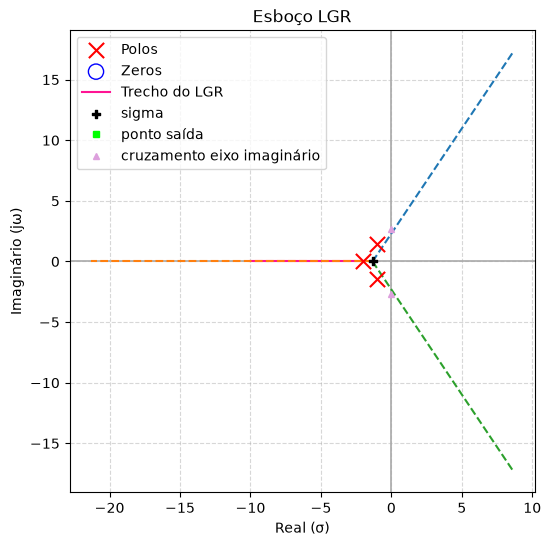

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites 

    # Desenha os Polos (X vermelho) e Zeros (O azul)
ax.scatter([p.real for p in polos], [p.imag for p in polos], 
            marker='x', color='red', s=120, label='Polos', zorder=3)
ax.scatter([z.real for z in zeros], [z.imag for z in zeros], 
            marker='o', color='blue', facecolors='none', s=120, label='Zeros', zorder=3)

ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

    # Configurações visuais finais do gráfico
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel('Real (σ)')
ax.set_ylabel('Imaginário (jω)')
ax.set_title(f'Esboço LGR')

for linha in linhas:
        primeira_linha = True
        if primeira_linha:
            ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink', label='Trecho do LGR') 
            primeira_linha = False
        else:
            ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink') 

plot_assintotas(ax, (sigma, 0), angulos_assintotas, 20)

x = [r.real for r in ponto_saida]
y = [r.imag for r in ponto_saida]

ax.plot(x, y, 'b.', markersize=5, label = "ponto saída", marker = 's', color = 'lime')

a = [sp.im(item) for sublist in eixo_img for item in sublist]

ax.plot(
    [0] * len(a), a,
    marker='^',
    linestyle='None',
    markersize=5,
    label="cruzamento eixo imaginário",
    color='plum'
)

plt.legend()
plt.show()